# Patient0_J35_2：扫描方向、重建参数与 Repositionnement 矢状图检查

本 notebook 整合扫描方向检查与 Repositionnement 矢状面检查，依次读取：

1. `data_recal_Patient0_J35_2_d_0.5.mat`
2. `data_3D_Patient0_J35_2_sagplan_params.mat`
3. `data_3D_Patient0_J35_2_reconstruction_points.mat`
4. `data_repos_Patient0_J35_2_sag.mat`

前三个文件用于检查扫描方向及重建参数，最后一个文件用于检查 Repositionnement 阶段的矢状面图像。

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/neuf_matplotlib")

import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data/cerebral_data").is_dir():
            return candidate
    for candidate in (Path("/home/zchen/Code/NeUF"), Path("/misc/raid/zchen/Code/NeUF")):
        if (candidate / "data/cerebral_data").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Cannot locate the NeUF project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
RECAL_PATH = PROJECT_ROOT / "data/cerebral_data/Pre_traitement_echo_v2/Recalage/Patient0/data_recal_Patient0_J35_2_d_0.5.mat"
SAGPLAN_PATH = PROJECT_ROOT / "data/cerebral_data/Pre_traitement_echo_v2/Reconstruction_3D/Patient0/data_3D_Patient0_J35_2_sagplan_params.mat"
POINTS_PATH = PROJECT_ROOT / "data/cerebral_data/Pre_traitement_echo_v2/Reconstruction_3D/Patient0/data_3D_Patient0_J35_2_reconstruction_points.mat"
MAT_PATH = PROJECT_ROOT / "data/cerebral_data/Pre_traitement_echo_v2/Repositionnement/Patient0/data_repos_Patient0_J35_2_sag.mat"
OUTPUT_DIR = PROJECT_ROOT / "notebooks/Patient0_J35_2_repositionnement_sag_check"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for path in (RECAL_PATH, SAGPLAN_PATH, POINTS_PATH, MAT_PATH):
    print(f"{path.name}: exists={path.exists()}, size={path.stat().st_size / 1024**2:.2f} MiB")

data_recal_Patient0_J35_2_d_0.5.mat: exists=True, size=60.56 MiB
data_3D_Patient0_J35_2_sagplan_params.mat: exists=True, size=0.18 MiB
data_3D_Patient0_J35_2_reconstruction_points.mat: exists=True, size=0.00 MiB
data_repos_Patient0_J35_2_sag.mat: exists=True, size=0.31 MiB


## 1. 读取配准后的扫描序列 `data_recal`

MATLAB v7.3 在 HDF5 中以相反的维度顺序保存数组，所以读取后用 `.transpose()` 恢复 MATLAB/Python 重建代码所使用的 `(height, width, frame)` 顺序。

Top-level fields: {'data_recal': 'Dataset', 't_form': 'Dataset'}
data_recal.shape = (708, 944, 242)  # (height, width, frame)
data_recal.dtype = uint8
intensity range = [0, 246]


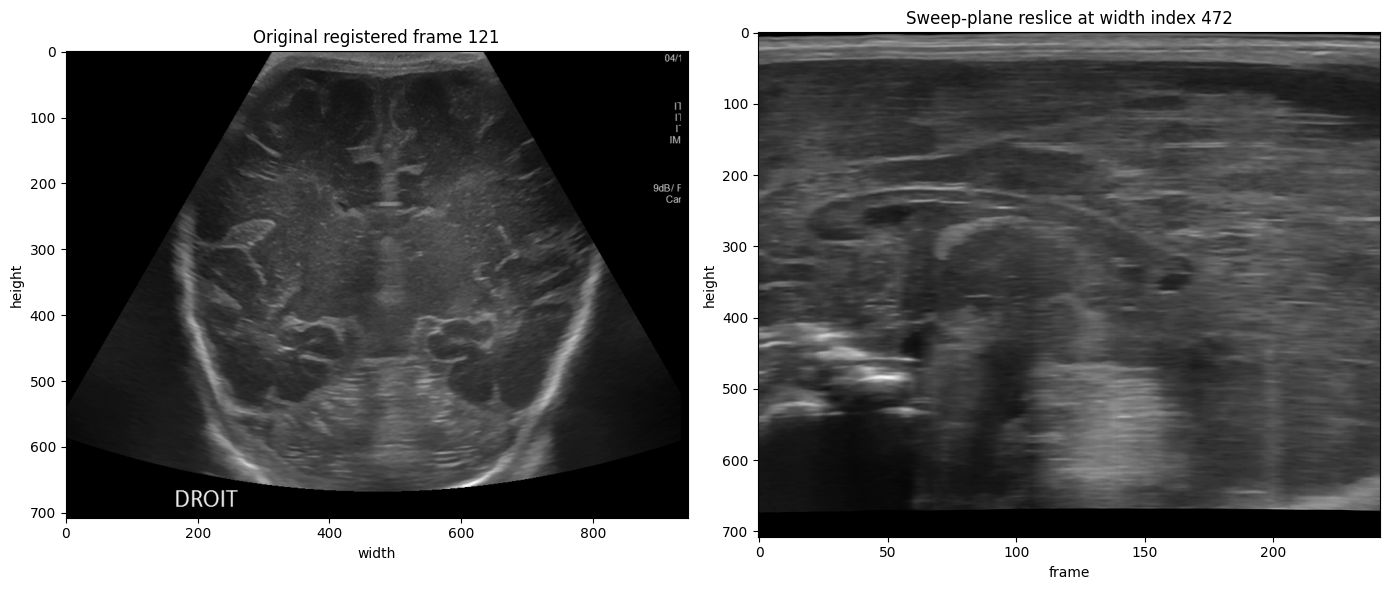

In [2]:
with h5py.File(RECAL_PATH, "r") as mat_file:
    top_level = {name: type(obj).__name__ for name, obj in mat_file.items() if not name.startswith("#")}
    print("Top-level fields:", top_level)
    data_recal = np.asarray(mat_file["data_recal"]).transpose()

print(f"data_recal.shape = {data_recal.shape}  # (height, width, frame)")
print(f"data_recal.dtype = {data_recal.dtype}")
print(f"intensity range = [{data_recal.min()}, {data_recal.max()}]")

frame_index = data_recal.shape[2] // 2
sweep_index = data_recal.shape[1] // 2
acquisition_frame = data_recal[:, :, frame_index]
sweep_plane = data_recal[:, sweep_index, :]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(acquisition_frame, cmap="gray")
axes[0].set_title(f"Original registered frame {frame_index}")
axes[0].set_xlabel("width")
axes[0].set_ylabel("height")
axes[1].imshow(sweep_plane, cmap="gray", aspect="auto")
axes[1].set_title(f"Sweep-plane reslice at width index {sweep_index}")
axes[1].set_xlabel("frame")
axes[1].set_ylabel("height")
fig.tight_layout()
plt.show()

## 2. 读取 `sagplan_params.mat`

该文件也是 MATLAB v7.3/HDF5。`img_cc_seqdyn` 是从动态扫描体中选择、重切得到的扫查平面图像。

P: shape=(3, 3), dtype=float64
all_num_img_cc: shape=(), dtype=float64
all_rect: shape=(4,), dtype=float64
coord_pts_sagplan: shape=(3, 3), dtype=float64
idx_sag: shape=(), dtype=float64
img_cc_seqdyn: shape=(708, 242), dtype=float64
tr_coord: shape=(3,), dtype=float64
idx_sag (MATLAB, 1-based) = 478
corresponding Python index = 477
img_cc_seqdyn.shape = (708, 242)
exact normalized reslice match = True
maximum absolute difference = 0.0


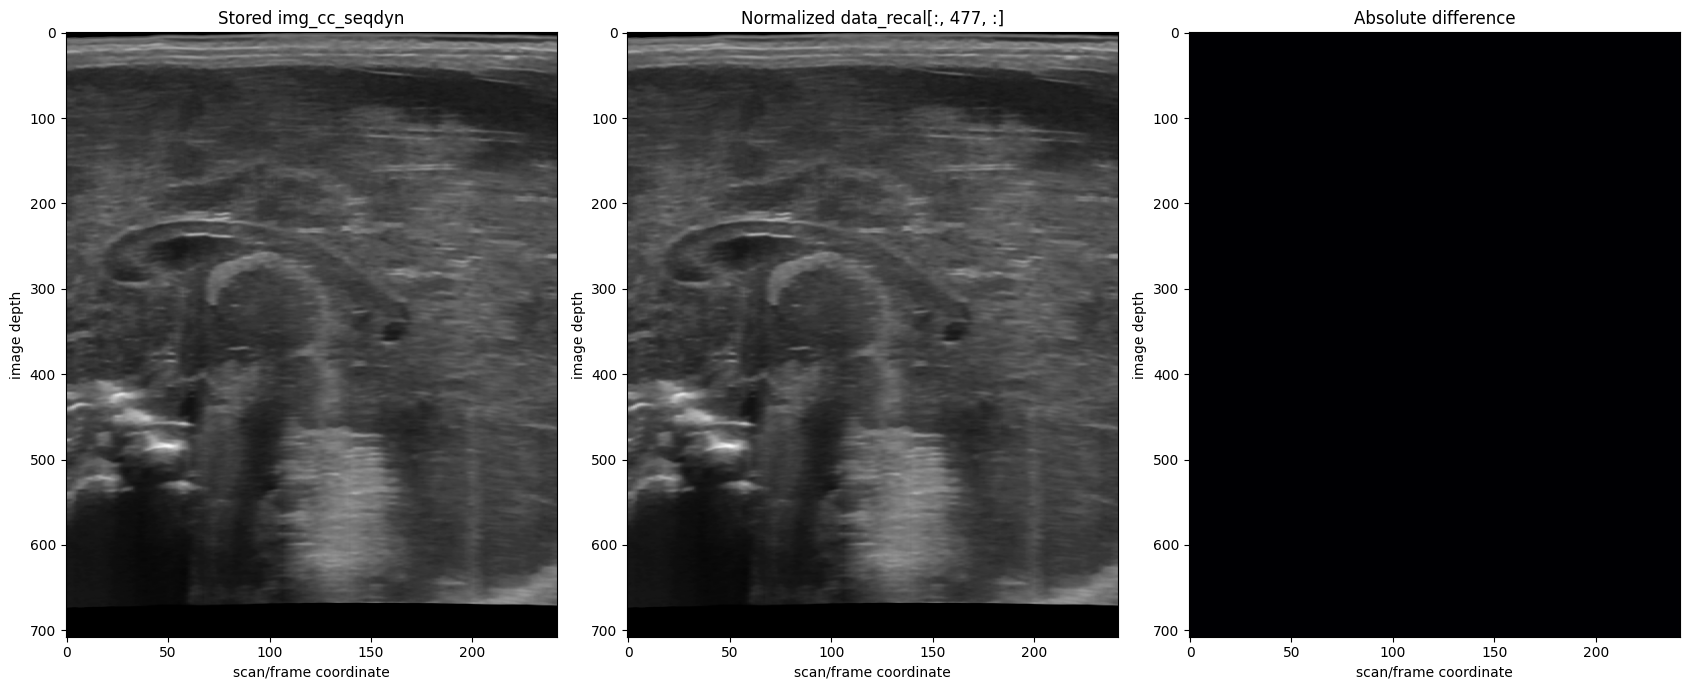

In [3]:
def read_matlab_v73_top_level(path: Path) -> dict[str, np.ndarray]:
    result = {}
    with h5py.File(path, "r") as mat_file:
        for name, obj in mat_file.items():
            if isinstance(obj, h5py.Dataset):
                array = np.asarray(obj)
                # MATLAB v7.3/HDF5 stores dimension order reversed.
                if array.ndim > 1:
                    array = array.transpose(tuple(reversed(range(array.ndim))))
                result[name] = np.squeeze(array)
    return result

sagplan = read_matlab_v73_top_level(SAGPLAN_PATH)
for name, value in sagplan.items():
    print(f"{name}: shape={np.shape(value)}, dtype={np.asarray(value).dtype}")

img_cc_seqdyn = sagplan["img_cc_seqdyn"]
idx_sag = int(np.asarray(sagplan["idx_sag"]).item())
python_index = idx_sag - 1  # idx_sag uses MATLAB's 1-based indexing.
slice_from_recal = data_recal[:, python_index, :].astype(float)
slice_from_recal /= slice_from_recal.max() if slice_from_recal.max() > 0 else 1.0
absolute_difference = np.abs(img_cc_seqdyn - slice_from_recal)

print(f"idx_sag (MATLAB, 1-based) = {idx_sag}")
print(f"corresponding Python index = {python_index}")
print(f"img_cc_seqdyn.shape = {img_cc_seqdyn.shape}")
print(f"exact normalized reslice match = {np.array_equal(img_cc_seqdyn, slice_from_recal)}")
print(f"maximum absolute difference = {absolute_difference.max()}")

fig, axes = plt.subplots(1, 3, figsize=(17, 7))
axes[0].imshow(img_cc_seqdyn, cmap="gray", aspect="auto")
axes[0].set_title("Stored img_cc_seqdyn")
axes[1].imshow(slice_from_recal, cmap="gray", aspect="auto")
axes[1].set_title(f"Normalized data_recal[:, {python_index}, :]")
axes[2].imshow(absolute_difference, cmap="magma", aspect="auto")
axes[2].set_title("Absolute difference")
for ax in axes:
    ax.set_xlabel("scan/frame coordinate")
    ax.set_ylabel("image depth")
fig.tight_layout()
plt.show()

## 3. 读取 `reconstruction_points.mat`

该文件保存参考图像和动态序列图像中的对应配准点，不包含新的图像数组。

coord_pts_img_ref: shape=(11, 2), dtype=float64
[[384.71290323 288.18129032]
 [448.35677419 224.53741935]
 [602.44193548 330.05225806]
 [550.52193548 422.1683871 ]
 [532.09870968 365.22387097]
 [443.33225806 311.62903226]
 [421.55935484 443.94129032]
 [364.61483871 495.86129032]
 [300.97096774 425.51806452]
 [505.30129032 532.70774194]
 [661.06129032 462.36451613]]
coord_pts_img_seqdyn: shape=(11, 2), dtype=float64
[[ 39.8364817  284.53896104]
 [ 58.22609209 213.27922078]
 [159.36894923 356.94805195]
 [113.39492326 452.34415584]
 [108.79752066 379.93506494]
 [ 69.71959858 314.42207792]
 [ 61.67414404 452.34415584]
 [ 51.32998819 516.70779221]
 [ 22.59622196 456.94155844]
 [ 91.55726092 555.78571429]
 [170.86245573 541.99350649]]


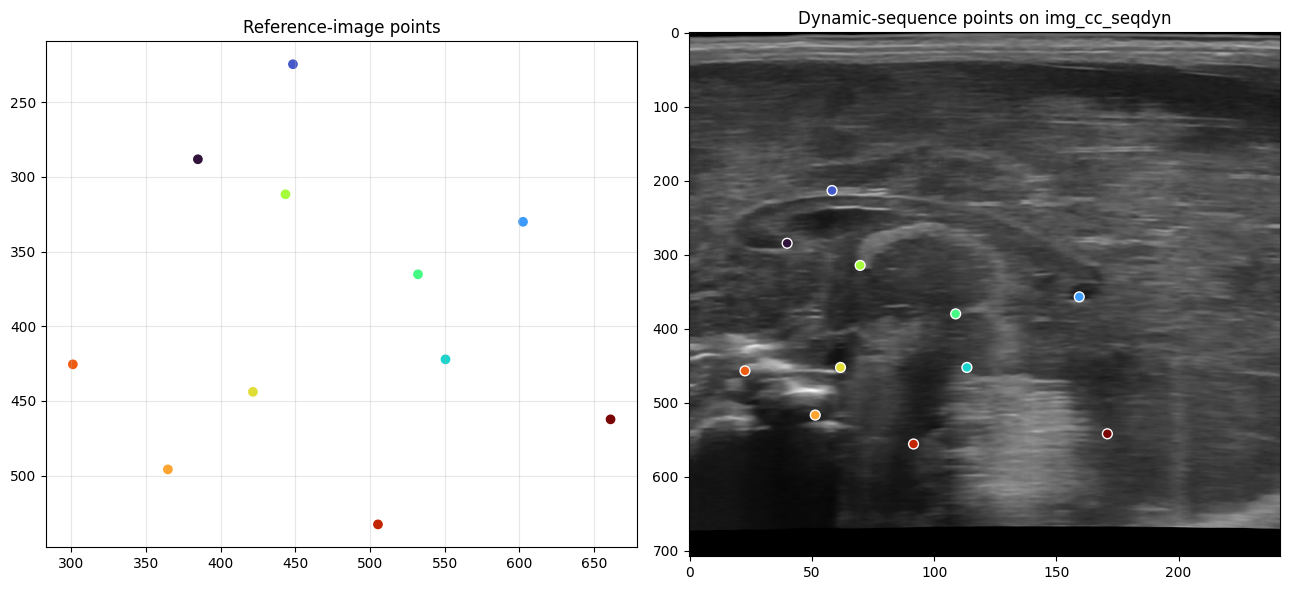

In [4]:
points_mat = loadmat(POINTS_PATH, simplify_cells=True)
reconstruction_points = {name: value for name, value in points_mat.items() if not name.startswith("__")}

for name, value in reconstruction_points.items():
    print(f"{name}: shape={value.shape}, dtype={value.dtype}")
    print(value)

coord_pts_img_ref = reconstruction_points["coord_pts_img_ref"]
coord_pts_img_seqdyn = reconstruction_points["coord_pts_img_seqdyn"]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].scatter(coord_pts_img_ref[:, 0], coord_pts_img_ref[:, 1], c=np.arange(len(coord_pts_img_ref)), cmap="turbo")
axes[0].invert_yaxis()
axes[0].set_title("Reference-image points")
axes[0].set_aspect("equal")
axes[0].grid(alpha=0.3)

axes[1].imshow(img_cc_seqdyn, cmap="gray", aspect="auto")
axes[1].scatter(
    coord_pts_img_seqdyn[:, 0],
    coord_pts_img_seqdyn[:, 1],
    c=np.arange(len(coord_pts_img_seqdyn)),
    cmap="turbo",
    edgecolors="white",
    s=50,
)
axes[1].set_title("Dynamic-sequence points on img_cc_seqdyn")
fig.tight_layout()
plt.show()

## 4. 读取 Repositionnement 阶段的 `data_sag`

该文件是 MATLAB v7.3/HDF5 格式。HDF5 中的维度顺序为 `(944, 708)`，转置后恢复为 MATLAB 图像尺寸 `(708, 944)`。

In [5]:
with h5py.File(MAT_PATH, "r") as mat_file:
    print("HDF5/MAT fields:")
    for name, obj in mat_file.items():
        print(f"  {name}: stored_shape={obj.shape}, dtype={obj.dtype}")
    # MATLAB v7.3 stores array dimensions in reverse order in HDF5.
    data_sag = np.asarray(mat_file["data_sag"]).transpose()

print(f"data_sag.shape = {data_sag.shape}")
print(f"data_sag.dtype = {data_sag.dtype}")
print(f"intensity range = [{data_sag.min()}, {data_sag.max()}]")
print(f"mean intensity = {data_sag.mean():.3f}")
print(f"non-zero pixels = {np.count_nonzero(data_sag):,} / {data_sag.size:,}")

HDF5/MAT fields:
  data_sag: stored_shape=(944, 708), dtype=uint8
data_sag.shape = (708, 944)
data_sag.dtype = uint8
intensity range = [0, 225]
mean intensity = 34.412
non-zero pixels = 489,274 / 668,352


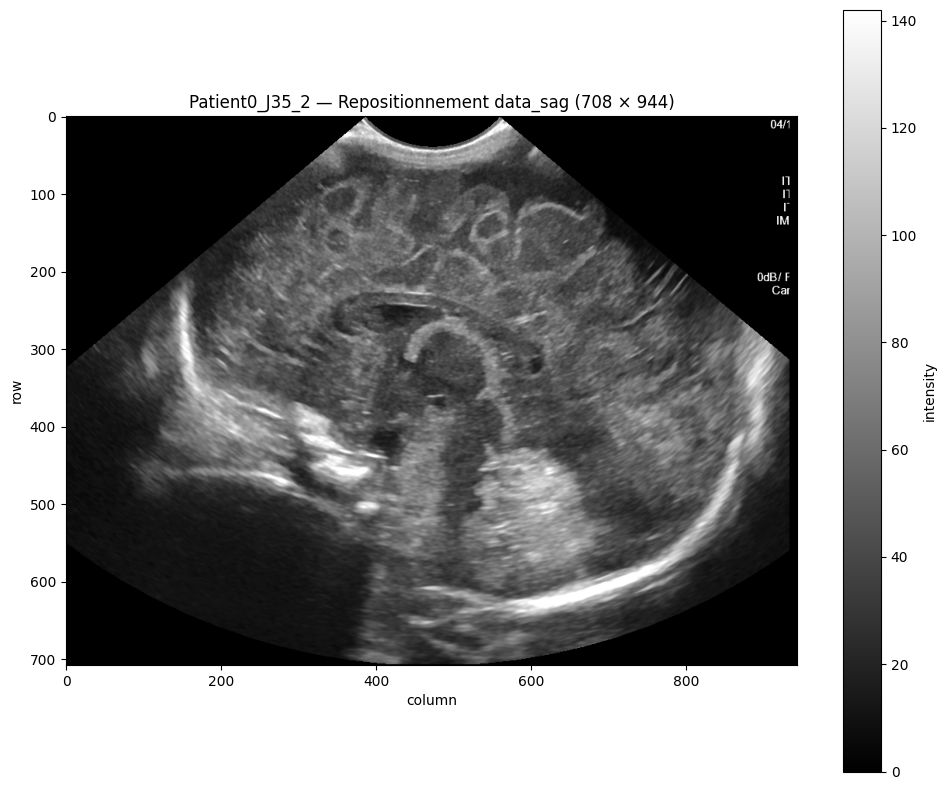

Saved preview: /misc/raid/zchen/Code/NeUF/notebooks/Patient0_J35_2_repositionnement_sag_check/data_sag_preview.png


In [6]:
nonzero = data_sag[data_sag > 0]
vmax = float(np.percentile(nonzero, 99.5)) if nonzero.size else 1.0

fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")
image = ax.imshow(data_sag, cmap="gray", vmin=0, vmax=vmax)
ax.set_title("Patient0_J35_2 — Repositionnement data_sag (708 × 944)")
ax.set_xlabel("column")
ax.set_ylabel("row")
fig.colorbar(image, ax=ax, label="intensity")
fig.tight_layout()
preview_path = OUTPUT_DIR / "data_sag_preview.png"
fig.savefig(preview_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved preview: {preview_path}")

## 结论

- `data_recal` 是形状为 `(708, 944, 242)` 的配准后 3D 扫描序列；既包含原始方向的帧堆栈，也可沿堆栈重切出另一方向。
- `sagplan_params.mat` 中的 `img_cc_seqdyn` 是归一化后的 `data_recal[:, 477, :]`（文件中 MATLAB 1 基索引 `idx_sag=478`），不是另一套独立采集。
- `reconstruction_points.mat` 只包含 `coord_pts_img_ref` 和 `coord_pts_img_seqdyn` 两组二维对应点。
- Repositionnement 文件只包含 `data_sag`：一张恢复维度后为 `(708, 944)` 的 `uint8` 二维矢状方向图像。